In [359]:
from utils import create_new_dataset, create_surv_data
from lifelines import KaplanMeierFitter, WeibullAFTFitter
from sksurv.metrics import concordance_index_ipcw
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
import seaborn as sns

# 1 monat krankmeldung

# zensierrate rumspielen ... %  an teil der zensierung  0.1 / 0.25 / 0.5
# Fallzahll rumspielen
# shape parameter 

# zeitabhängige kovariate, da weibull modell(zur schätzun )  es schwierieger hat

# logistic regression theroetische wahre varainz möglich 
# vergleichen mit empirischer standardabweichung 

# streuung von blanche schätzung varanzschätzer mit streuung von jackknife schätzer vergleichen

# 05-18.08 frau jahn urlaub 
# registerdatrem 5600 = n

# logistische regression / cox / xgb / random forest 

# nachlesen random forest standardfehler schätzung 

# registerdaten 85 % tensierung 

### Datensatz erstellen

In [384]:
import numpy as np
import pandas as pd
from lifelines import WeibullAFTFitter
import matplotlib.pyplot as plt

n = 1000
seed = 42

df = create_surv_data(shape_weibull=1,   # constant hazard
                        scale_weibull_base=10000, 
                        rate_censoring=0.01,  
                        b_bloodp=-0.405, 
                        b_diab=-0.4, 
                        b_age=-0.05, 
                        b_bmi=-0.01, 
                        b_kreat=-0.2,
                        n=n, 
                        seed=42)

#df.boxplot(column='t', by='event', grid=True)
#plt.show()

# cutpoint for the time t
t = 75
df = create_new_dataset(df,t)
df['survived'].value_counts(normalize=True)

#df.head(10)

Data shape: (1000, 7)
34.0 % of the data has an event


survived
999    0.459
1      0.290
0      0.251
Name: proportion, dtype: float64

### Tranformation der Kovariaten

In [385]:
df['bmi'] = (df['bmi']-25)**2
df['kreatinkinase'] = np.log(df['kreatinkinase'])

### Train und Testsplit

In [386]:
X = df[['bmi', 'blood_pressure', 'kreatinkinase', 'diabetes', 'age']]
y = Surv.from_arrays(event=df['event'], time=df['t'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

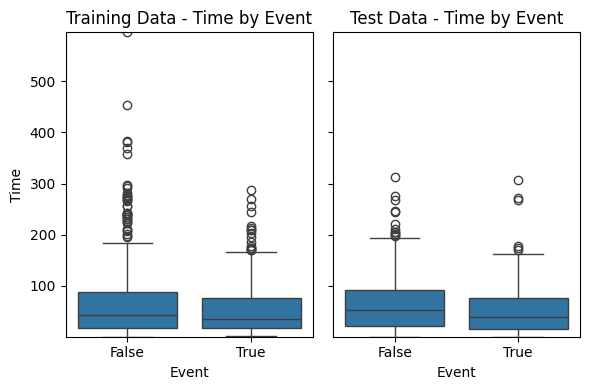

Relative Häufigkeiten der Events - Trainingsdaten:
event
False    0.66
True     0.34
Name: proportion, dtype: float64

Relative Häufigkeiten der Events - Testdaten:
event
False    0.66
True     0.34
Name: proportion, dtype: float64


In [364]:
y_train_df = pd.DataFrame({'event': [event for event, time in y_train], 'time': [time for event, time in y_train]})
y_test_df = pd.DataFrame({'event': [event for event, time in y_test], 'time': [time for event, time in y_test]})

fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)
sns.boxplot(ax=axes[0], x='event', y='time', data=y_train_df)
axes[0].set_title('Training Data - Time by Event')
axes[0].set_xlabel('Event')
axes[0].set_ylabel('Time')
sns.boxplot(ax=axes[1], x='event', y='time', data=y_test_df)
axes[1].set_title('Test Data - Time by Event')
axes[1].set_xlabel('Event')
axes[1].set_ylabel('Time')
y_min = min(y_train_df['time'].min(), y_test_df['time'].min())
y_max = max(y_train_df['time'].max(), y_test_df['time'].max())
axes[0].set_ylim(y_min, y_max)
axes[1].set_ylim(y_min, y_max)
plt.tight_layout()
plt.show()

train_event_counts = y_train_df['event'].value_counts(normalize=True)
test_event_counts = y_test_df['event'].value_counts(normalize=True)
print("Relative Häufigkeiten der Events - Trainingsdaten:")
print(train_event_counts)
print("\nRelative Häufigkeiten der Events - Testdaten:")
print(test_event_counts)

df_train = X_train.copy()
df_test = X_test.copy()
df_train.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)

y_train_df.reset_index(drop=True, inplace=True)
y_test_df.reset_index(drop=True, inplace=True)

df_train['event'] = y_train_df['event']
df_train['time'] = y_train_df['time']
df_test['event'] = y_test_df['event']
df_test['time'] = y_test_df['time']

# speicher df_train als csv hoch
df_train.to_csv('df_train.csv', index=False)
df_test.to_csv('df_test.csv', index=False)

### Weibull Modell fitten

In [387]:
aft = WeibullAFTFitter()
aft.fit(df_train, duration_col='time', event_col='event')
aft.print_summary()

""" df = create_surv_data(shape_weibull=1,   # constant hazard
                        scale_weibull_base=10000, 
                        rate_censoring=0.01,  
                        b_bloodp=-0.405, 
                        b_diab=-0.4, 
                        b_age=-0.05, 
                        b_bmi=-0.01, 
                        b_kreat=-0.2,
                        n=n, 
                        seed=42) """

#aft.plot()

<lifelines.WeibullAFTFitter: fitted with 700 total observations, 462 right-censored observations>
             duration col = 'time'
                event col = 'event'
   number of observations = 700
number of events observed = 238
           log-likelihood = -1426.19
         time fit was run = 2024-07-29 20:13:51 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                       
lambda_ age            -0.05      0.95      0.01           -0.07           -0.04                0.94                0.96
        blood_pressure -0.43      0.65      0.14           -0.70           -0.17                0.50                0.84
        bmi            -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
        diabetes       -0.64      0.53      0.15           -0.94           -0.34                0.39                0.71
        kreatinkinase  -0.23      0.80      0.07           -0.36           -0.09                0.70                0.91
        Intercept       9.53  13701.26      0.55            8.44           10.61             4645.77            40407.57
rho_    Intercept       0.00      1.00      0.05           -0.10            0.10                0.91                1.10

                        cmp to     z      p  -log2(p)
param   covariate                                    
lambda_ age               0.00 -7.10 <0.005     39.55
        blood_pressure    0.00 -3.21 <0.005      9.57
        bmi               0.00 -5.69 <0.005     26.22
        diabetes          0.00 -4.23 <0.005     15.40
        kreatinkinase     0.00 -3.33 <0.005     10.18
        Intercept         0.00 17.26 <0.005    219.38
rho_    Intercept         0.00  0.01   0.99      0.01
---
Concordance = 0.69
AIC = 2866.38
log-likelihood ratio test = 113.36 on 5 df
-log2(p) of ll-ratio test = 73.41

' df = create_surv_data(shape_weibull=1,   # constant hazard\n                        scale_weibull_base=10000, \n                        rate_censoring=0.01,  \n                        b_bloodp=-0.405, \n                        b_diab=-0.4, \n                        b_age=-0.05, \n                        b_bmi=-0.01, \n                        b_kreat=-0.2,\n                        n=n, \n                        seed=42) '

### Weibull Modell evaluation

In [388]:
tied_risk_scores = aft.predict_expectation(df_train)

# IPCW-C-Index berechnen
ci_ipcw, concordant, discordant, tied_risk, tied_time = concordance_index_ipcw(
    y_train, y_train, -tied_risk_scores )


print("IPCW-C-Index:", ci_ipcw)


IPCW-C-Index: 0.6740393506695707


In [389]:
# Kaplan-Meier-Schätzung für Zensierverteilung
kmf = KaplanMeierFitter()
kmf.fit(df['t'], event_observed=1-df['event'])
censoring_prob = 1 - kmf.survival_function_at_times([t]).values[0]
censoring_prob_after_t = 1-censoring_prob
print(censoring_prob_after_t)

# IPC-Gewichte 



df['ipc_weight'] = 1 / censoring_prob_after_t
#data_bi.loc[data['event'] == 0, 'ipc_weight'] = 


# cutpoint for the time t
t = 150
data_bi = create_new_dataset(df,t)
data_bi['survived'].value_counts(normalize=True)

NameError: name 'data' is not defined

In [14]:
data_bi['ipc_weight'].sum()

1.5380413332677234